In [4]:
!pip install yfinance arch scipy matplotlib pandas numpy

Kupiec Test: 2.132594224496785
Christoffersen Test: 0.7867092287967807


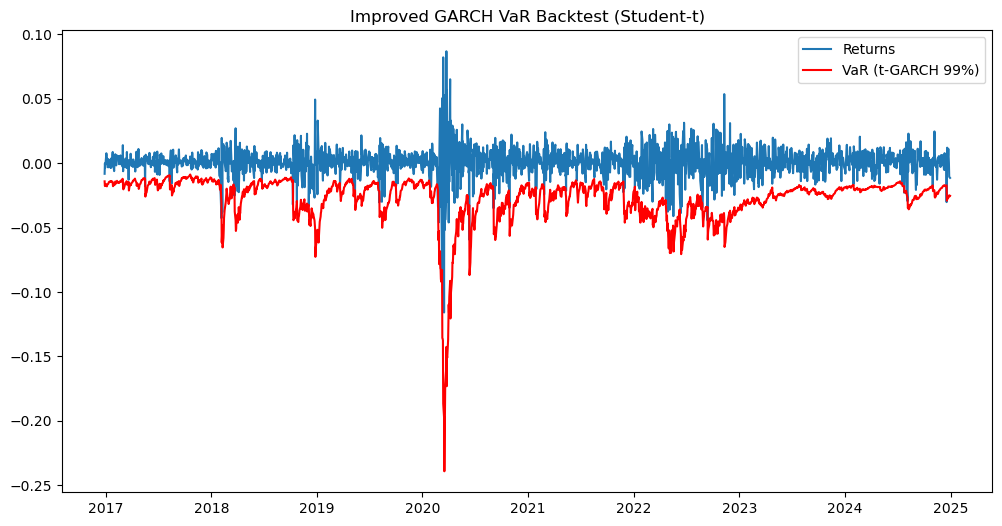

Expected Shortfall (99%): 0.03165532612123077


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from arch import arch_model
import scipy.stats as stats

# =========================
# 1. DATA
# =========================
def load_data(ticker="SPY", start="2015-01-01", end="2024-12-31"):
    data = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    return data["Close"].dropna()

# =========================
# 2. RETURNS
# =========================
def compute_returns(prices):
    return np.log(prices / prices.shift(1)).dropna()

# =========================
# 3. GARCH (Student-t FIX)
# =========================
def fit_garch(returns):
    model = arch_model(
        returns * 100,
        vol="Garch",
        p=1,
        q=1,
        dist="t"   # 🔥 FIX: fat tails
    )
    res = model.fit(disp="off")
    return res

def forecast_volatility(model_fit):
    f = model_fit.forecast(horizon=1)
    var = f.variance.values[-1, 0]
    return np.sqrt(var) / 100

# =========================
# 4. VaR + ES (t-distribution)
# =========================
def calculate_var_t(volatility, alpha=0.99, df=10):
    t_crit = stats.t.ppf(1 - alpha, df)
    return t_crit * volatility

def calculate_es_t(volatility, alpha=0.99, df=10):
    t_crit = stats.t.ppf(1 - alpha, df)
    pdf = stats.t.pdf(t_crit, df)
    es = (df + t_crit**2) / (df - 1) * (pdf / (1 - alpha)) * volatility
    return es

# =========================
# 5. BACKTEST TESTS
# =========================
def kupiec_test(violations, alpha):
    v = np.array(violations)
    n = len(v)
    x = np.sum(v)

    if n == 0 or x == 0 or x == n:
        return np.nan

    pi = x / n

    return -2 * (
        (n - x) * np.log(1 - alpha) + x * np.log(alpha)
        - (n - x) * np.log(1 - pi) - x * np.log(pi)
    )

def christoffersen_test(violations):
    v = np.array(violations).astype(int)

    if len(v) < 2:
        return np.nan

    n00 = n01 = n10 = n11 = 0

    for i in range(1, len(v)):
        if v[i-1] == 0 and v[i] == 0: n00 += 1
        elif v[i-1] == 0 and v[i] == 1: n01 += 1
        elif v[i-1] == 1 and v[i] == 0: n10 += 1
        elif v[i-1] == 1 and v[i] == 1: n11 += 1

    pi01 = n01 / (n00 + n01 + 1e-12)
    pi11 = n11 / (n10 + n11 + 1e-12)
    pi = (n01 + n11) / (n00 + n01 + n10 + n11 + 1e-12)

    return -2 * (
        (n00 * np.log(1 - pi) + n01 * np.log(pi) +
         n10 * np.log(1 - pi) + n11 * np.log(pi))
        -
        (n00 * np.log(1 - pi01) + n01 * np.log(pi01) +
         n10 * np.log(1 - pi11) + n11 * np.log(pi11))
    )

# =========================
# 6. MAIN LOOP (FIXED + ROLLING RE-FIT)
# =========================
prices = load_data()
returns = compute_returns(prices)

window = 500
alpha = 0.99

var_list = []
violations = []

for i in range(window, len(returns)):

    train = returns.iloc[i-window:i]

    try:
        model = fit_garch(train)  # 🔥 rolling re-estimation
        vol = forecast_volatility(model)

        var = calculate_var_t(vol, alpha)

        actual = returns.iloc[i].item()  # FIX WARNING

        var_list.append(var)
        violations.append(int(actual < var))

    except Exception:
        continue

var_list = np.array(var_list)
violations = np.array(violations)

eval_returns = returns.iloc[window:window + len(var_list)]

# =========================
# 7. RESULTS
# =========================
kupiec = kupiec_test(violations, 1 - alpha)
christoffersen = christoffersen_test(violations)

print("Kupiec Test:", kupiec)
print("Christoffersen Test:", christoffersen)

# =========================
# 8. PLOT
# =========================
plt.figure(figsize=(12,6))
plt.plot(eval_returns.index, eval_returns.values, label="Returns")
plt.plot(eval_returns.index, var_list, label="VaR (t-GARCH 99%)", color="red")
plt.title("Improved GARCH VaR Backtest (Student-t)")
plt.legend()
plt.show()

# =========================
# 9. ES
# =========================
last_model = fit_garch(returns.iloc[-window:])
last_vol = forecast_volatility(last_model)

es = calculate_es_t(last_vol, alpha)

print("Expected Shortfall (99%):", es)

Portfolio VaR (99%): -0.02608008045730166
Portfolio ES (99%): -0.029433988547418598


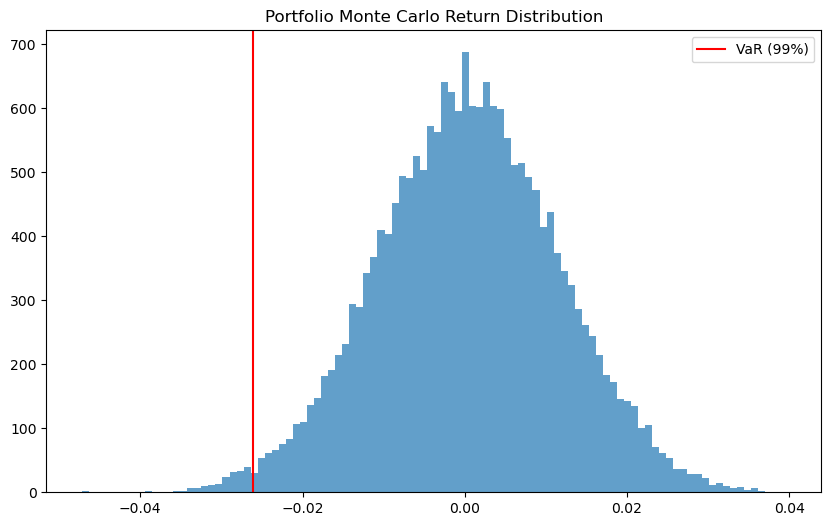

In [15]:
# =========================
# PORTFOLIO VaR EXTENSION (RUN AFTER YOUR CURRENT CODE)
# =========================

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# -------------------------
# 1. LOAD MULTI-ASSET DATA
# -------------------------
tickers = ["SPY", "QQQ", "IWM", "TLT"]

prices = yf.download(
    tickers,
    start="2015-01-01",
    end="2024-12-31",
    auto_adjust=True,
    progress=False
)["Close"]

prices = prices.dropna()

# -------------------------
# 2. RETURNS
# -------------------------
returns = np.log(prices / prices.shift(1)).dropna()

# -------------------------
# 3. PORTFOLIO WEIGHTS
# -------------------------
weights = np.array([0.4, 0.3, 0.2, 0.1])

# -------------------------
# 4. MONTE CARLO VaR (CHOLESKY)
# -------------------------
def portfolio_mc_var(returns, weights, alpha=0.99, sims=20000):

    mu = returns.mean().values
    cov = returns.cov().values

    # Cholesky decomposition
    L = np.linalg.cholesky(cov)

    n_assets = len(weights)

    # random shocks
    z = np.random.normal(size=(sims, n_assets))
    correlated = z @ L.T

    # add drift
    simulated = correlated + mu

    # portfolio returns
    port_returns = simulated @ weights

    # VaR + ES
    var = np.quantile(port_returns, 1 - alpha)
    es = port_returns[port_returns <= var].mean()

    return var, es, port_returns

# -------------------------
# 5. RUN MODEL
# -------------------------
var, es, sim_dist = portfolio_mc_var(returns, weights)

print("Portfolio VaR (99%):", var)
print("Portfolio ES (99%):", es)

# -------------------------
# 6. PLOT DISTRIBUTION
# -------------------------
plt.figure(figsize=(10,6))
plt.hist(sim_dist, bins=100, alpha=0.7)
plt.axvline(var, color="red", label="VaR (99%)")
plt.title("Portfolio Monte Carlo Return Distribution")
plt.legend()
plt.show()

EWMA Portfolio VaR (99%): -0.024015499713205685
EWMA Portfolio ES (99%): -0.027770328031511762
STRESS VaR (COVID-like shock): -0.0417740807184019
STRESS ES (COVID-like shock): -0.047941199399813346


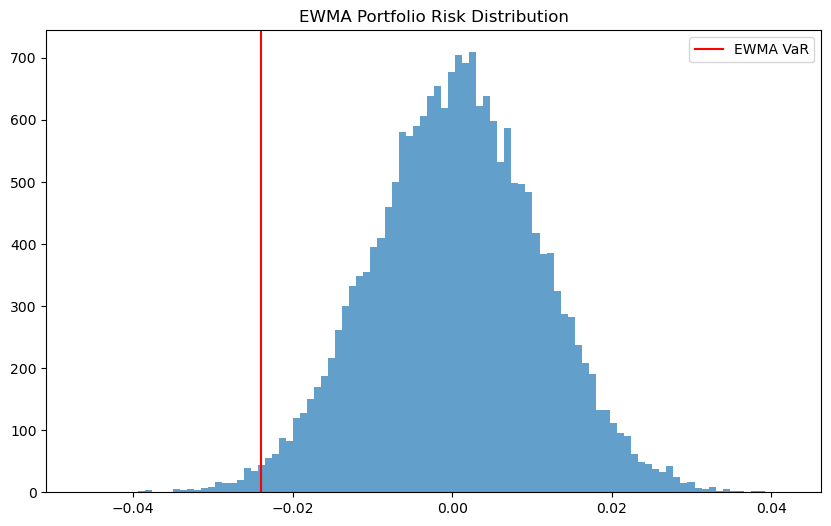

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. EWMA COVARIANCE
# =========================
def ewma_cov(returns, lambda_=0.94):
    """
    RiskMetrics-style EWMA covariance
    """
    cov = np.zeros((returns.shape[1], returns.shape[1]))
    r = returns.values

    for t in range(len(r)):
        rt = r[t].reshape(-1, 1)
        cov = lambda_ * cov + (1 - lambda_) * (rt @ rt.T)

    return cov

# =========================
# 2. ROLLING COVARIANCE
# =========================
def rolling_cov(returns, window=60):
    return returns.tail(window).cov().values

# =========================
# 3. STRESS SCENARIO (COVID SHOCK STYLE)
# =========================
def stress_test(returns, weights, shock=2.5):
    """
    Apply volatility shock multiplier (e.g., COVID-like regime)
    """
    cov = returns.cov().values * shock
    mean = returns.mean().values

    L = np.linalg.cholesky(cov)
    z = np.random.normal(size=(20000, len(weights)))

    sim = z @ L.T + mean
    port = sim @ weights

    var = np.quantile(port, 0.01)
    es = port[port <= var].mean()

    return var, es

# =========================
# 4. RUN MODELS
# =========================

weights = np.array([0.4, 0.3, 0.2, 0.1])

# Use your existing returns (from previous cell)
# returns = ...

# EWMA risk
ewma_cov_matrix = ewma_cov(returns)

# Rolling risk (last 60 days)
roll_cov_matrix = rolling_cov(returns, window=60)

# =========================
# 5. MONTE CARLO USING EWMA
# =========================
def mc_with_cov(returns, weights, cov_matrix, sims=20000):

    mean = returns.mean().values
    L = np.linalg.cholesky(cov_matrix)

    z = np.random.normal(size=(sims, len(weights)))
    sim = z @ L.T + mean

    port = sim @ weights

    var = np.quantile(port, 0.01)
    es = port[port <= var].mean()

    return var, es, port

ewma_var, ewma_es, ewma_dist = mc_with_cov(returns, weights, ewma_cov_matrix)

# Stress test
stress_var, stress_es = stress_test(returns, weights)

# =========================
# 6. RESULTS
# =========================
print("EWMA Portfolio VaR (99%):", ewma_var)
print("EWMA Portfolio ES (99%):", ewma_es)

print("STRESS VaR (COVID-like shock):", stress_var)
print("STRESS ES (COVID-like shock):", stress_es)

# =========================
# 7. VISUAL
# =========================
plt.figure(figsize=(10,6))
plt.hist(ewma_dist, bins=100, alpha=0.7)
plt.axvline(ewma_var, color="red", label="EWMA VaR")
plt.title("EWMA Portfolio Risk Distribution")
plt.legend()
plt.show()

In [19]:
print("=== FINAL RISK SUMMARY ===")
print("Portfolio VaR (99%):", var)
print("Portfolio ES (99%):", es)
print("Stress VaR:", stress_var)
print("Stress ES:", stress_es)

=== FINAL RISK SUMMARY ===
Portfolio VaR (99%): -0.02608008045730166
Portfolio ES (99%): -0.029433988547418598
Stress VaR: -0.0417740807184019
Stress ES: -0.047941199399813346
